In [1]:
# EXPERIMENTO 3 (INTERVENCIONAL): barrido de beta sobre los 11 datasets sinteticos, bajo do(x2 = 0).
# Mismas condiciones que Datasets_Sinteticos_Observacional.ipynb (N de entrenamiento en {50, 100},
# N=100 de test, 10 semillas); lo que cambia es que el modelo se ENTRENA con datos observacionales
# y se EVALUA bajo intervencion, siguiendo Experimento1/Intervencional.
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))

import time
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.metrics import mmd, rf
from src.models.kan import kan_model_mixed
from src.datasets.synthetic import graph_data


# --- [PASO 1: FUNCIONES AUXILIARES] ---

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuracion de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()

def clave_run(dataset, seed, n, beta):
    """Identificador de un run. Sirve para no reentrenar lo que ya esta en el CSV."""
    return (str(dataset), int(seed), int(n), round(float(beta), 5))

def model_intervention(model, node, value, n, var_names, seed=42):
    """Muestras del MODELO KAN bajo do(node = value)."""
    # v=value captura el valor por defecto; un cierre libre colapsaria al ultimo valor del bucle
    intervention = {node: (lambda _, v=value: v)}
    return model.interventional_samples(intervention, num_samples_to_draw=n, seed=seed)[var_names]


# --- [PASO 2: CONFIGURACION DEL EXPERIMENTO] ---

# Los 11 datasets del benchmark continuo del paper (misma lista que paper_plots.ipynb).
datasets_evaluados = ['3-chain-linear', '3-chain-non-linear', '4-chain-linear', '5-chain-linear',
                      'collider-linear', 'fork-linear', 'fork-non-linear', 'simpson-non-linear',
                      'simpson-symprod', 'triangle-linear', 'triangle-non-linear']

# N_actual es el tamano del conjunto de ENTRENAMIENTO; la evaluacion siempre usa 100 muestras fijas.
valores_N_experimento = [50, 100]
# Barrido completo de beta. Los que ya esten en el CSV NO se reentrenan (ver reanudacion mas abajo).
valores_beta_candidatos = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
semillas_experimento = np.arange(42, 52)  # 10 semillas (42-51)

# La intervencion es siempre la misma: do(x2 = 0), un nodo presente en los 11 datasets.
NODO_INTERVENIDO = 'x2'
VALOR_DO = 0.0
# graph_data devuelve data_cf = [cf_x1(-1), cf_x1(0), cf_x1(1), cf_x2(-1), cf_x2(0), cf_x2(1)],
# asi que el indice 4 es justamente el ground truth bajo do(x2 = 0).
INDICE_CF_DO = 4

# Conjunto de evaluacion FIJO por dataset: todas las semillas, N y betas se evaluan siempre contra las
# mismas 100 muestras intervencionales, generadas una unica vez con una semilla propia.
N_EVAL_FIJO = 100
SEED_EVAL_FIJO = 9999

# Metricas de este experimento, todas medidas bajo do(x2 = 0).
metricas_experimento = ['RF Acc', 'MMD', 'MAE x3']

base_cols = ['Dataset', 'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'Do']

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}


# --- [PASO 2b: REANUDACION - no se reentrena nada que ya este en el CSV] ---
# Los KANs no se guardan en disco: lo que se conserva son las filas de metricas ya calculadas. Al
# releerlas, cualquier combinacion (Dataset, Seed, N, Beta) que ya exista se omite, de modo que
# anadir betas nuevos solo entrena los betas nuevos.
carpeta_tablas = "tablas"
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)
ruta_archivo = os.path.join(carpeta_tablas, "datasets_sinteticos_intervencional.csv")

if os.path.exists(ruta_archivo):
    df_previo = pd.read_csv(ruta_archivo)
    runs_hechos = {clave_run(r.Dataset, r.Seed, r.N, r.Beta) for r in df_previo.itertuples(index=False)}
    print(f"Reanudando desde {ruta_archivo}: {len(df_previo)} runs ya calculados "
          f"(betas {sorted(df_previo['Beta'].unique())}) -> no se reentrenan.")
else:
    df_previo = pd.DataFrame()
    runs_hechos = set()
    print("No hay CSV previo: se entrena el barrido completo desde cero.")

registros_tabla_final = []
t_inicio_global = time.time()

total_runs = len(datasets_evaluados) * len(semillas_experimento) * len(valores_N_experimento) * len(valores_beta_candidatos)
runs_pendientes = sum(1 for d in datasets_evaluados for s in semillas_experimento
                      for n in valores_N_experimento for b in valores_beta_candidatos
                      if clave_run(d, s, n, b) not in runs_hechos)
print(f"Rejilla completa: {total_runs} runs "
      f"({len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas x {len(valores_N_experimento)} N x {len(valores_beta_candidatos)} betas)")
print(f"Pendientes de entrenar: {runs_pendientes}")


def guardar_checkpoint():
    """Vuelca a CSV lo previo + lo nuevo. Permite interrumpir y reanudar sin perder trabajo."""
    if not registros_tabla_final:
        return
    df_ckpt = pd.concat([df_previo, pd.DataFrame(registros_tabla_final)], ignore_index=True)
    df_ckpt = df_ckpt[base_cols + metricas_experimento].sort_values(by=['Dataset', 'N', 'Beta', 'Seed'])
    df_ckpt.to_csv(ruta_archivo, index=False)


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACION] ---

for dataset in datasets_evaluados:
    print("\n" + "#"*70)
    print(f"DATASET: {dataset}  |  do({NODO_INTERVENIDO} = {VALOR_DO})")
    print("#"*70)

    # El entrenamiento es observacional; la evaluacion usa el ground truth intervencional data_cf[4].
    factual_eval_d, data_cf_eval, graph_ds, _ = graph_data(name=dataset).generate(num_samples=N_EVAL_FIJO, seed=SEED_EVAL_FIJO)
    # El orden de graph_ds.nodes NO coincide con el de las columnas en collider/fork: usar var_names.
    var_names = list(factual_eval_d.columns)
    eval_int_d = data_cf_eval[INDICE_CF_DO][var_names]
    datos_reales_int = eval_int_d.to_numpy()
    num_muestras_eval = len(eval_int_d)

    node_types = {nodo: 'continuous' for nodo in graph_ds.nodes}
    num_classes = {}

    print(f"  Nodos: {var_names} | Aristas: {list(graph_ds.edges)} | Padres de x3: {list(graph_ds.predecessors('x3'))}")

    for experiment_id, seed in enumerate(semillas_experimento, start=1):
        for N_actual in valores_N_experimento:
            factual_train_d, _, _, _ = graph_data(name=dataset).generate(num_samples=N_actual, seed=int(seed))

            for beta_val in valores_beta_candidatos:
                # Ya calculado en una ejecucion anterior: se conserva su fila del CSV y no se reentrena.
                if clave_run(dataset, seed, N_actual, beta_val) in runs_hechos:
                    continue

                # Misma convencion que el Experimento 1: beta=0 es MSE puro, beta>0 es hibrido con alpha=1-beta.
                if beta_val == 0.0:
                    strategy_name, alpha_val = "mse", 1.0
                else:
                    strategy_name, alpha_val = "hybrid", round(1.0 - beta_val, 2)

                params_estructurados = crear_estructura_nodos(
                    graph_ds, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
                )

                print(f" -> {dataset} | semilla={seed} | N={N_actual} | beta={beta_val} ({strategy_name.upper()})")
                model = kan_model_mixed(graph_ds, params_estructurados)
                model.fit(data=factual_train_d)

                conf_name = "MSE" if strategy_name == "mse" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
                fila = {
                    'Dataset': dataset,
                    'Experiment': experiment_id,
                    'Seed': int(seed),
                    'Loss': strategy_name,
                    'Conf': conf_name,
                    'Alpha': alpha_val,
                    'Beta': beta_val,
                    'N': N_actual,
                    'Do': f'{NODO_INTERVENIDO}={VALOR_DO}'
                }

                try:
                    # MAE x3: residuo de la ecuacion estructural de x3 medido sobre el conjunto intervencional.
                    residuos = model.get_residuals(eval_int_d)
                    r_x3 = preparar_residuo(residuos['x3'])
                    fila['MAE x3'] = round(float(np.mean(np.abs(r_x3))), 5)

                    # MMD y RF Acc: muestras del modelo bajo do(x2=0) contra el ground truth bajo do(x2=0).
                    datos_gen = model_intervention(model, NODO_INTERVENIDO, VALOR_DO, num_muestras_eval, var_names).to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_int, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_int, datos_gen)), 5)

                except Exception as e:
                    print(f"   [Error en evaluacion] {dataset} | {conf_name} | N={N_actual} | semilla={seed}: {e}")

                registros_tabla_final.append(fila)

    # Checkpoint tras cada dataset: si se interrumpe la ejecucion, al relanzarla se reanuda aqui.
    guardar_checkpoint()


# --- [PASO 4: TABLA MAESTRA] ---
# Lo ya calculado (df_previo) + lo entrenado en esta ejecucion (registros_tabla_final).
df_nuevos = pd.DataFrame(registros_tabla_final)
df_final = pd.concat([df_previo, df_nuevos], ignore_index=True) if len(df_previo) else df_nuevos
df_final = df_final[base_cols + metricas_experimento]
df_final = df_final.sort_values(by=['Dataset', 'N', 'Beta', 'Seed']).reset_index(drop=True)

print(f"\n--- MATRIZ DE DIAGNOSTICO INTERVENCIONAL FINALIZADA ---")
print(f"    {len(df_final)} runs en total | {len(df_nuevos)} entrenados ahora "
      f"| {len(df_previo)} reutilizados | {time.time() - t_inicio_global:.0f} s")
display(df_final)

# --- [PASO 5: GUARDADO EN CSV] ---
df_final.to_csv(ruta_archivo, index=False)
print(f"Tabla maestra guardada en: {ruta_archivo}")

Reanudando desde tablas\datasets_sinteticos_intervencional.csv: 1980 runs ya calculados (betas [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8)]) -> no se reentrenan.
Rejilla completa: 1980 runs (11 datasets x 10 semillas x 2 N x 9 betas)
Pendientes de entrenar: 0

######################################################################
DATASET: 3-chain-linear  |  do(x2 = 0.0)
######################################################################
  Nodos: ['x1', 'x2', 'x3'] | Aristas: [('x1', 'x2'), ('x2', 'x3')] | Padres de x3: ['x2']

######################################################################
DATASET: 3-chain-non-linear  |  do(x2 = 0.0)
######################################################################
  Nodos: ['x1', 'x2', 'x3'] | Aristas: [('x1', 'x2'), ('x2', 'x3')] | Padres de x3: ['x2']

######################################################################
DATAS

,Dataset,Experiment,Seed,Loss,Conf,Alpha,Beta,N,Do,RF Acc,MMD,MAE x3
0,3-chain-linear,1,42,mse,MSE,1.0,0.0,50,x2=0.0,0.600,0.02562,0.83093
1,3-chain-linear,2,43,mse,MSE,1.0,0.0,50,x2=0.0,0.550,0.01756,0.83318
2,3-chain-linear,3,44,mse,MSE,1.0,0.0,50,x2=0.0,0.525,0.01034,0.83322
3,3-chain-linear,4,45,mse,MSE,1.0,0.0,50,x2=0.0,0.625,0.02805,0.83063
4,3-chain-linear,5,46,mse,MSE,1.0,0.0,50,x2=0.0,0.650,0.01889,0.83267
...,...,...,...,...,...,...,...,...,...,...,...,...
1975,triangle-non-linear,6,47,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,x2=0.0,0.600,0.06752,0.91382
1976,triangle-non-linear,7,48,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,x2=0.0,0.600,0.01889,0.29579
1977,triangle-non-linear,8,49,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,x2=0.0,0.725,0.03475,0.62921
1978,triangle-non-linear,9,50,hybrid,HYBRID_ALPHA0.2_BETA0.8,0.2,0.8,100,x2=0.0,0.875,0.09558,0.69889


Tabla maestra guardada en: tablas\datasets_sinteticos_intervencional.csv


In [2]:
# PASO 6: resumen media +/- std sobre las 10 semillas, para cada combinacion (Dataset, N, Beta).
print("\n" + "="*100)
print("TABLA RESUMEN INTERVENCIONAL do(x2=0.0): MEDIA +/- DESVIACION TIPICA POR DATASET, N Y BETA")
print("="*100)

resumen_por_dataset = []
for (dataset, n_val, beta_val), grupo in df_final.groupby(['Dataset', 'N', 'Beta']):
    fila_resumen = {
        'Dataset': dataset,
        'N': n_val,
        'Beta': beta_val,
        'Alpha': grupo['Alpha'].iloc[0],
        'Loss': grupo['Loss'].iloc[0],
        'Num_Seeds': len(grupo)
    }
    for metrica in metricas_experimento:
        fila_resumen[f'{metrica}_mean'] = round(float(grupo[metrica].mean()), 5)
        fila_resumen[f'{metrica}_std'] = round(float(grupo[metrica].std()), 5)
    resumen_por_dataset.append(fila_resumen)

df_resumen = pd.DataFrame(resumen_por_dataset).sort_values(['Dataset', 'N', 'Beta']).reset_index(drop=True)
display(df_resumen)

ruta_resumen = os.path.join("tablas", "resumen_por_dataset_intervencional.csv")
df_resumen.to_csv(ruta_resumen, index=False)
print(f"\nTabla resumen guardada en: {ruta_resumen}")

# Version legible "media +/- std", un bloque por (dataset, N).
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media +/- Std por dataset y N")
print(f"{'='*100}")
for dataset in datasets_evaluados:
    for n_val in valores_N_experimento:
        df_ds = df_resumen[(df_resumen['Dataset'] == dataset) & (df_resumen['N'] == n_val)]
        if df_ds.empty:
            continue
        tabla_legible = {}
        for _, r in df_ds.iterrows():
            tabla_legible[f"Beta={r['Beta']}"] = [f"{r[f'{m}_mean']:.5f} +/- {r[f'{m}_std']:.5f}" for m in metricas_experimento]
        print(f"\n{'-'*100}\n{dataset}  |  N = {n_val}\n{'-'*100}")
        display(pd.DataFrame(tabla_legible, index=metricas_experimento))


TABLA RESUMEN INTERVENCIONAL do(x2=0.0): MEDIA +/- DESVIACION TIPICA POR DATASET, N Y BETA


,Dataset,N,Beta,Alpha,Loss,Num_Seeds,RF Acc_mean,RF Acc_std,MMD_mean,MMD_std,MAE x3_mean,MAE x3_std
0,3-chain-linear,50,0.0,1.0,mse,10,0.5900,0.05028,0.02330,0.01695,0.83913,0.02051
1,3-chain-linear,50,0.1,0.9,hybrid,10,0.5875,0.04751,0.02352,0.01917,0.84121,0.02512
2,3-chain-linear,50,0.2,0.8,hybrid,10,0.5925,0.04417,0.02364,0.02090,0.84154,0.02897
3,3-chain-linear,50,0.3,0.7,hybrid,10,0.6000,0.03536,0.02204,0.01613,0.83835,0.01882
4,3-chain-linear,50,0.4,0.6,hybrid,10,0.5850,0.03944,0.02223,0.01836,0.83751,0.01618
...,...,...,...,...,...,...,...,...,...,...,...,...
193,triangle-non-linear,100,0.4,0.6,hybrid,10,0.6600,0.06476,0.02160,0.00816,0.32392,0.06892
194,triangle-non-linear,100,0.5,0.5,hybrid,10,0.6800,0.09413,0.02648,0.01614,0.39394,0.19650
195,triangle-non-linear,100,0.6,0.4,hybrid,10,0.6675,0.06460,0.02472,0.02087,0.32387,0.07871
196,triangle-non-linear,100,0.7,0.3,hybrid,10,0.6800,0.07710,0.03092,0.02212,0.40600,0.15903



Tabla resumen guardada en: tablas\resumen_por_dataset_intervencional.csv


FORMATO LEGIBLE: Media +/- Std por dataset y N

----------------------------------------------------------------------------------------------------
3-chain-linear  |  N = 50
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.1,Beta=0.2,Beta=0.3,Beta=0.4,Beta=0.5,Beta=0.6,Beta=0.7,Beta=0.8
RF Acc,0.59000 +/- 0.05028,0.58750 +/- 0.04751,0.59250 +/- 0.04417,0.60000 +/- 0.03536,0.58500 +/- 0.03944,0.59250 +/- 0.03129,0.59750 +/- 0.03988,0.59750 +/- 0.04632,0.59500 +/- 0.04378
MMD,0.02330 +/- 0.01695,0.02352 +/- 0.01917,0.02364 +/- 0.02090,0.02204 +/- 0.01613,0.02223 +/- 0.01836,0.02258 +/- 0.01970,0.02232 +/- 0.01935,0.01638 +/- 0.00390,0.01642 +/- 0.00395
MAE x3,0.83913 +/- 0.02051,0.84121 +/- 0.02512,0.84154 +/- 0.02897,0.83835 +/- 0.01882,0.83751 +/- 0.01618,0.83940 +/- 0.02201,0.84072 +/- 0.02606,0.83261 +/- 0.00133,0.83237 +/- 0.00135



----------------------------------------------------------------------------------------------------
3-chain-linear  |  N = 100
----------------------------------------------------------------------------------------------------


...

,Beta=0.0,Beta=0.1,Beta=0.2,Beta=0.3,Beta=0.4,Beta=0.5,Beta=0.6,Beta=0.7,Beta=0.8
RF Acc,0.59750 +/- 0.03810,0.59000 +/- 0.02108,0.61250 +/- 0.04449,0.57500 +/- 0.04410,0.55500 +/- 0.05244,0.59500 +/- 0.05244,0.59250 +/- 0.06129,0.58500 +/- 0.07472,0.58750 +/- 0.06897
MMD,0.03544 +/- 0.00723,0.03293 +/- 0.00770,0.03130 +/- 0.00984,0.03159 +/- 0.00904,0.03202 +/- 0.00964,0.03294 +/- 0.00811,0.03178 +/- 0.00864,0.03211 +/- 0.00782,0.02925 +/- 0.00668
MAE x3,3.55239 +/- 4.78830,3.12944 +/- 4.35716,2.59662 +/- 3.34050,2.22717 +/- 3.15695,4.98817 +/- 11.24439,5.78753 +/- 14.30375,4.51916 +/- 9.57000,3.86940 +/- 6.48171,1.51738 +/- 1.53934



----------------------------------------------------------------------------------------------------
triangle-non-linear  |  N = 50
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.1,Beta=0.2,Beta=0.3,Beta=0.4,Beta=0.5,Beta=0.6,Beta=0.7,Beta=0.8
RF Acc,0.67500 +/- 0.09718,0.69000 +/- 0.08010,0.66750 +/- 0.12079,0.70250 +/- 0.08933,0.70750 +/- 0.10412,0.69250 +/- 0.08337,0.70750 +/- 0.06460,0.71000 +/- 0.06032,0.71000 +/- 0.05426
MMD,0.04385 +/- 0.02000,0.04562 +/- 0.02361,0.04316 +/- 0.02668,0.04549 +/- 0.02572,0.04258 +/- 0.02731,0.04640 +/- 0.02289,0.05798 +/- 0.02115,0.04921 +/- 0.01962,0.06026 +/- 0.02439
MAE x3,0.85936 +/- 0.63714,0.91743 +/- 0.83390,0.97831 +/- 1.03017,1.06223 +/- 1.09221,0.85469 +/- 0.77061,1.06252 +/- 0.84185,1.12860 +/- 0.93971,1.59350 +/- 1.58971,1.15741 +/- 0.57884



----------------------------------------------------------------------------------------------------
triangle-non-linear  |  N = 100
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.1,Beta=0.2,Beta=0.3,Beta=0.4,Beta=0.5,Beta=0.6,Beta=0.7,Beta=0.8
RF Acc,0.65250 +/- 0.05197,0.67500 +/- 0.05401,0.66500 +/- 0.05916,0.67250 +/- 0.06061,0.66000 +/- 0.06476,0.68000 +/- 0.09413,0.66750 +/- 0.06460,0.68000 +/- 0.07710,0.67500 +/- 0.08660
MMD,0.02522 +/- 0.00745,0.02610 +/- 0.00994,0.02756 +/- 0.01326,0.02125 +/- 0.00570,0.02160 +/- 0.00816,0.02648 +/- 0.01614,0.02472 +/- 0.02087,0.03092 +/- 0.02212,0.03780 +/- 0.02902
MAE x3,0.46277 +/- 0.30325,0.56005 +/- 0.41636,0.49781 +/- 0.25238,0.32757 +/- 0.07449,0.32392 +/- 0.06892,0.39394 +/- 0.19650,0.32387 +/- 0.07871,0.40600 +/- 0.15903,0.50334 +/- 0.24134



VISUALIZACION INTERVENCIONAL do(x2=0.0): MEDIA Y DESVIACION TIPICA POR METRICA
(Linea = Media sobre las 10 semillas | Area sombreada = Media +/- Std | Un color = un dataset)
(Una figura por cada N)

Grafica guardada: plots\bandplot_datasets_intervencional_n_50.png



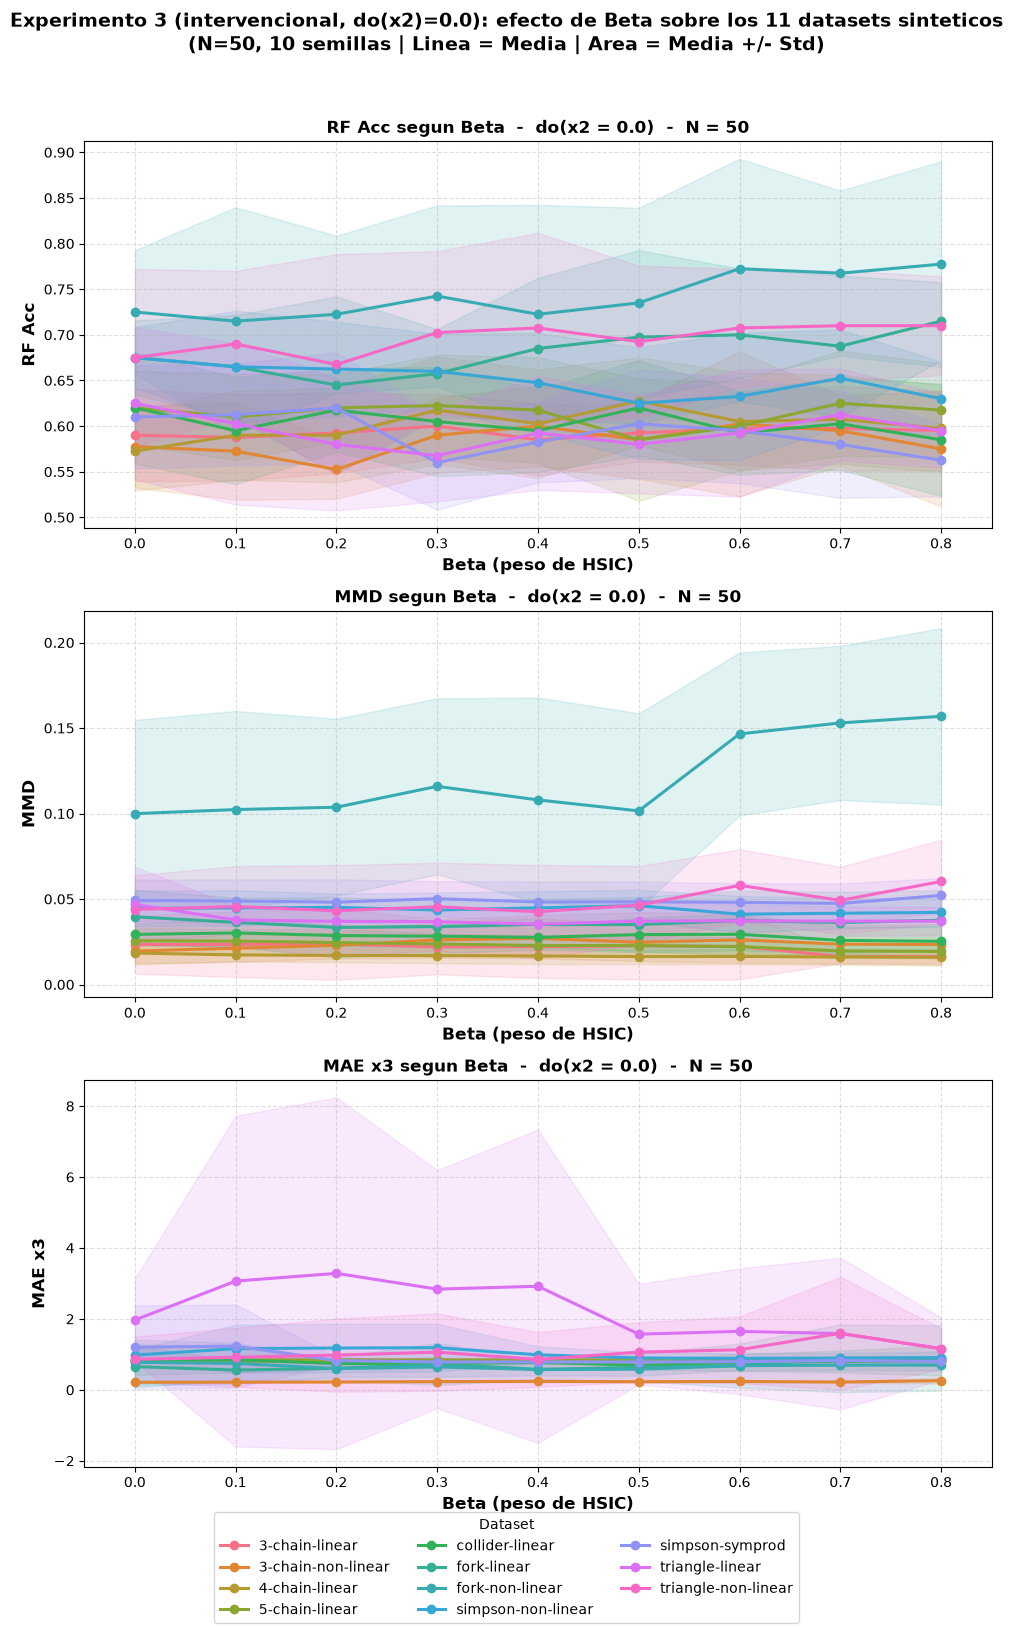

Grafica guardada: plots\bandplot_datasets_intervencional_n_100.png



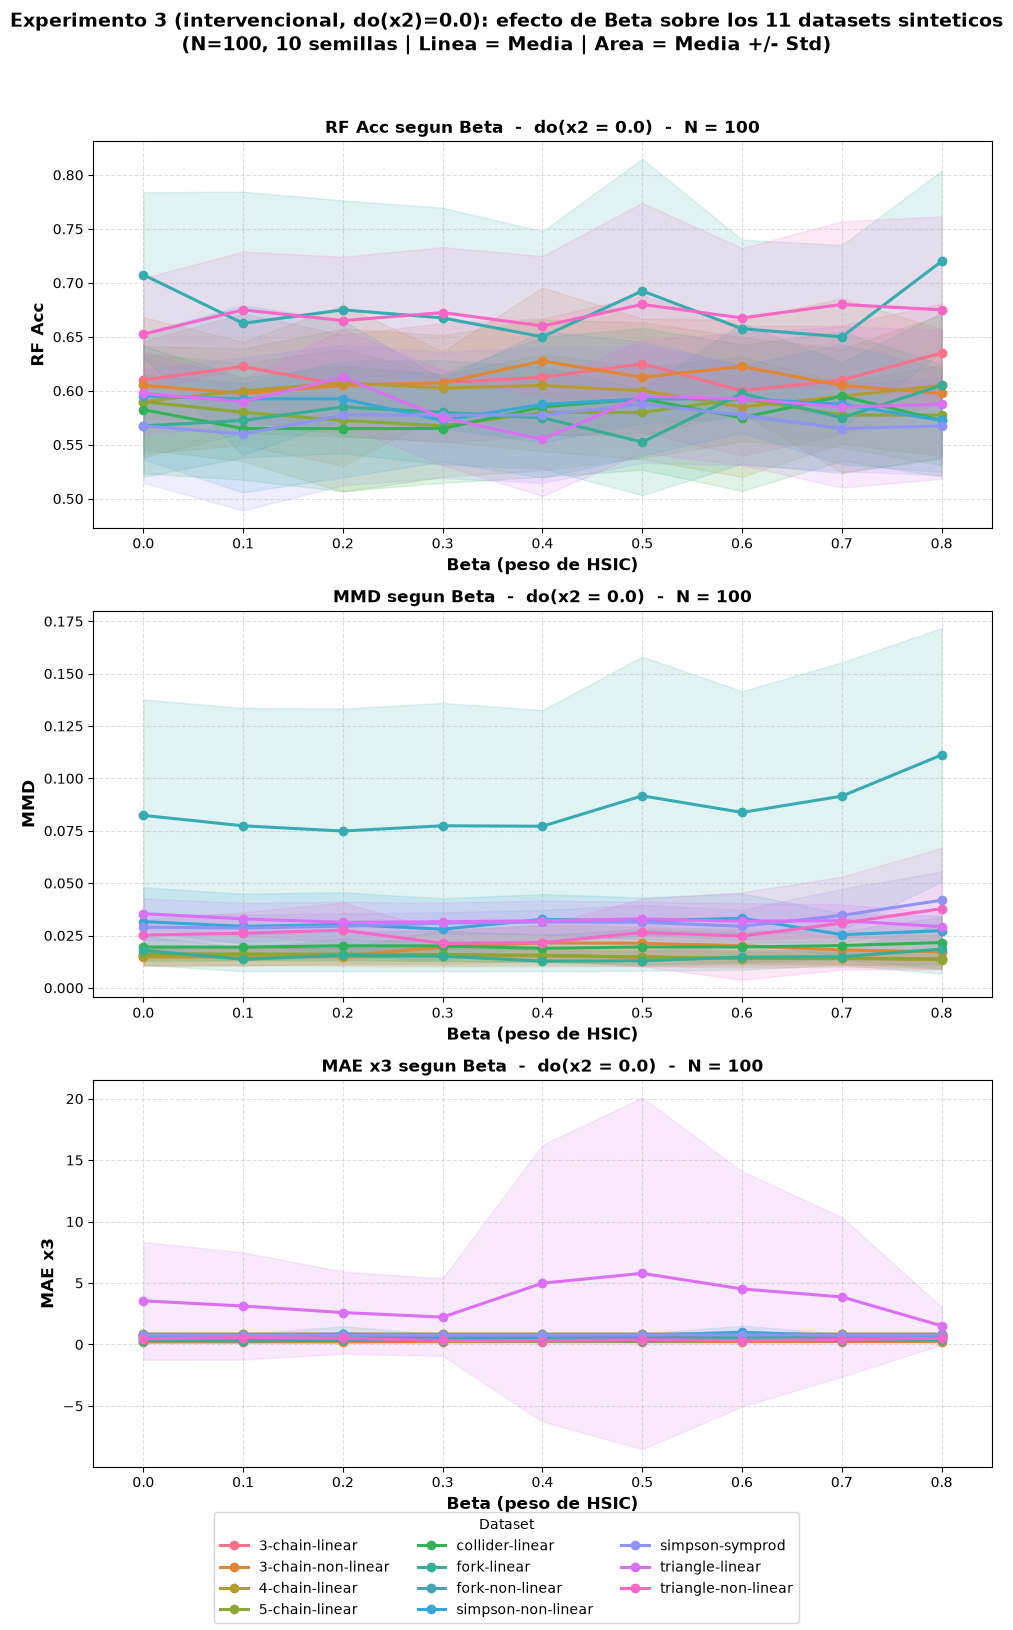

In [3]:
# PASO 7: una grafica por metrica (RF Acc, MMD, MAE x3)  -  do(x2 = 0.0). Eje X = beta, una curva por dataset,
# linea = media sobre las 10 semillas y banda sombreada = media +/- desviacion tipica.
# Una figura por cada N: mezclar los dos N en el mismo panel daria 22 curvas ilegibles.
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACION INTERVENCIONAL do(x2=0.0): MEDIA Y DESVIACION TIPICA POR METRICA")
print("(Linea = Media sobre las 10 semillas | Area sombreada = Media +/- Std | Un color = un dataset)")
print("(Una figura por cada N)")
print("="*100 + "\n")

colores_ds = sns.color_palette("husl", len(datasets_evaluados))
paleta_ds = dict(zip(datasets_evaluados, colores_ds))

if not os.path.exists('plots'):
    os.makedirs('plots')

for n_val in valores_N_experimento:
    df_n = df_resumen[df_resumen['N'] == n_val]
    if df_n.empty:
        continue

    # Las 3 metricas se apilan en vertical: una fila por metrica.
    fig, axes = plt.subplots(len(metricas_experimento), 1, figsize=(10, 5.5 * len(metricas_experimento)))
    fig.suptitle('Experimento 3 (intervencional, do(x2)=0.0): efecto de Beta sobre los 11 datasets sinteticos\n'
                 f'(N={n_val}, {len(semillas_experimento)} semillas | Linea = Media | Area = Media +/- Std)',
                 fontsize=14, fontweight='bold')

    for ax, metrica in zip(axes, metricas_experimento):
        for dataset in datasets_evaluados:
            df_ds = df_n[df_n['Dataset'] == dataset].sort_values('Beta')
            x = df_ds['Beta'].values
            y_mean = df_ds[f'{metrica}_mean'].values
            y_std = np.nan_to_num(df_ds[f'{metrica}_std'].values)

            ax.plot(x, y_mean, marker='o', linewidth=2.2, markersize=6, color=paleta_ds[dataset], label=dataset)
            ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=paleta_ds[dataset])

        ax.set_xlabel('Beta (peso de HSIC)', fontsize=12, fontweight='bold')
        ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
        ax.set_title(f'{metrica} segun Beta  -  do(x2 = 0.0)  -  N = {n_val}', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xticks(valores_beta_candidatos)
        ax.set_xlim(min(valores_beta_candidatos) - 0.05, max(valores_beta_candidatos) + 0.05)

    # Una unica leyenda compartida para los 11 datasets, debajo de la figura.
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10, frameon=True, title='Dataset')
    plt.tight_layout(rect=[0, 0.06, 1, 0.96])

    ruta_plot = os.path.join('plots', f'bandplot_datasets_intervencional_n_{n_val}.png')
    plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
    print(f"Grafica guardada: {ruta_plot}\n")
    plt.show()

In [4]:
# PASO 8: tabla final por (N, beta). Filas = las 3 metricas, columnas = mean y std, agregando los
# 11 datasets x 10 semillas (110 runs por celda). Es la tabla que se comparara contra otros modelos.
print("\n" + "="*100)
print(f"TABLA FINAL INTERVENCIONAL do(x2=0.0): MEDIA Y DESVIACION TIPICA POR N Y BETA "
      f"({len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas)")
print("="*100)

registros_finales = []
for n_val in valores_N_experimento:
    for beta_val in valores_beta_candidatos:
        df_beta = df_final[(df_final['N'] == n_val) & (np.isclose(df_final['Beta'], beta_val))]
        if df_beta.empty:
            continue
        tabla_beta = pd.DataFrame(
            {'mean': [df_beta[m].mean() for m in metricas_experimento],
             'std': [df_beta[m].std() for m in metricas_experimento]},
            index=metricas_experimento
        ).round(5)

        print(f"\n{'-'*60}\nN = {n_val}  |  Beta = {beta_val}  (Alpha = {round(1.0 - beta_val, 2)}, n_runs = {len(df_beta)})\n{'-'*60}")
        display(tabla_beta)

        for metrica in metricas_experimento:
            registros_finales.append({
                'N': n_val,
                'Beta': beta_val,
                'Metrica': metrica,
                'mean': round(float(df_beta[metrica].mean()), 5),
                'std': round(float(df_beta[metrica].std()), 5)
            })

df_final_resumen = pd.DataFrame(registros_finales)

# Vista compacta: una fila por metrica, una columna por (N, beta), en formato "media +/- std".
print(f"\n\n{'='*100}")
print("VISTA COMPACTA: filas = metricas, columnas = (N, Beta)")
print(f"{'='*100}\n")
tabla_compacta = {}
for n_val in valores_N_experimento:
    for beta_val in valores_beta_candidatos:
        sub = df_final_resumen[(df_final_resumen['N'] == n_val) & (df_final_resumen['Beta'] == beta_val)]
        if sub.empty:
            continue
        col = []
        for metrica in metricas_experimento:
            r = sub[sub['Metrica'] == metrica].iloc[0]
            col.append(f"{r['mean']:.5f} +/- {r['std']:.5f}")
        tabla_compacta[f"N={n_val}, Beta={beta_val}"] = col
display(pd.DataFrame(tabla_compacta, index=metricas_experimento))

ruta_final = os.path.join("tablas", "resumen_final_por_beta_intervencional.csv")
df_final_resumen.to_csv(ruta_final, index=False)
print(f"\nTabla final guardada en: {ruta_final}")


TABLA FINAL INTERVENCIONAL do(x2=0.0): MEDIA Y DESVIACION TIPICA POR N Y BETA (11 datasets x 10 semillas)

------------------------------------------------------------
N = 50  |  Beta = 0.0  (Alpha = 1.0, n_runs = 110)
------------------------------------------------------------


,mean,std
RF Acc,0.63318,0.07303
MMD,0.04001,0.02973
MAE x3,0.90830,0.71066



------------------------------------------------------------
N = 50  |  Beta = 0.1  (Alpha = 0.9, n_runs = 110)
------------------------------------------------------------


,mean,std
RF Acc,0.62773,0.08038
MMD,0.03939,0.03023
MAE x3,1.02088,1.59291



------------------------------------------------------------
N = 50  |  Beta = 0.2  (Alpha = 0.8, n_runs = 110)
------------------------------------------------------------


...


------------------------------------------------------------
N = 100  |  Beta = 0.8  (Alpha = 0.2, n_runs = 110)
------------------------------------------------------------


,mean,std
RF Acc,0.61045,0.07545
MMD,0.03147,0.03398
MAE x3,0.70383,0.55634




VISTA COMPACTA: filas = metricas, columnas = (N, Beta)



,"N=50, Beta=0.0","N=50, Beta=0.1","N=50, Beta=0.2","N=50, Beta=0.3","N=50, Beta=0.4","N=50, Beta=0.5","N=50, Beta=0.6","N=50, Beta=0.7","N=50, Beta=0.8","N=100, Beta=0.0","N=100, Beta=0.1","N=100, Beta=0.2","N=100, Beta=0.3","N=100, Beta=0.4","N=100, Beta=0.5","N=100, Beta=0.6","N=100, Beta=0.7","N=100, Beta=0.8"
RF Acc,0.63318 +/- 0.07303,0.62773 +/- 0.08038,0.62455 +/- 0.07999,0.62955 +/- 0.07892,0.63068 +/- 0.08230,0.63114 +/- 0.08171,0.63614 +/- 0.08841,0.63977 +/- 0.07966,0.63273 +/- 0.08665,0.60591 +/- 0.06451,0.60159 +/- 0.06934,0.60568 +/- 0.06978,0.59955 +/- 0.06452,0.60136 +/- 0.06914,0.61000 +/- 0.07679,0.60545 +/- 0.06330,0.60227 +/- 0.06709,0.61045 +/- 0.07545
MMD,0.04001 +/- 0.02973,0.03939 +/- 0.03023,0.03883 +/- 0.03001,0.04026 +/- 0.03214,0.03912 +/- 0.03190,0.03910 +/- 0.03034,0.04408 +/- 0.03921,0.04237 +/- 0.04044,0.04421 +/- 0.04258,0.02746 +/- 0.02554,0.02627 +/- 0.02483,0.02646 +/- 0.02488,0.02645 +/- 0.02507,0.02676 +/- 0.02454,0.02839 +/- 0.02969,0.02725 +/- 0.02686,0.02819 +/- 0.02961,0.03147 +/- 0.03398
MAE x3,0.90830 +/- 0.71066,1.02088 +/- 1.59291,0.99242 +/- 1.65979,0.97307 +/- 1.22806,0.92608 +/- 1.45359,0.81241 +/- 0.58560,0.84703 +/- 0.69279,0.90659 +/- 0.90027,0.83479 +/- 0.48318,0.87388 +/- 1.63637,0.83292 +/- 1.46983,0.79695 +/- 1.15568,0.73172 +/- 1.04899,0.98629 +/- 3.47980,1.07575 +/- 4.38029,0.98074 +/- 2.98572,0.90493 +/- 2.09893,0.70383 +/- 0.55634



Tabla final guardada en: tablas\resumen_final_por_beta_intervencional.csv



VISUALIZACION DE LA TABLA FINAL INTERVENCIONAL do(x2=0.0): MEDIA +/- STD AGREGADA POR BETA
(Una figura por N | Linea = Media | Area sombreada = Media +/- Std)
(Eje derecho = % de cambio respecto a beta=0, que marca el 0%)

Grafica guardada: plots\bandplot_resumen_final_por_beta_intervencional_n_50.png



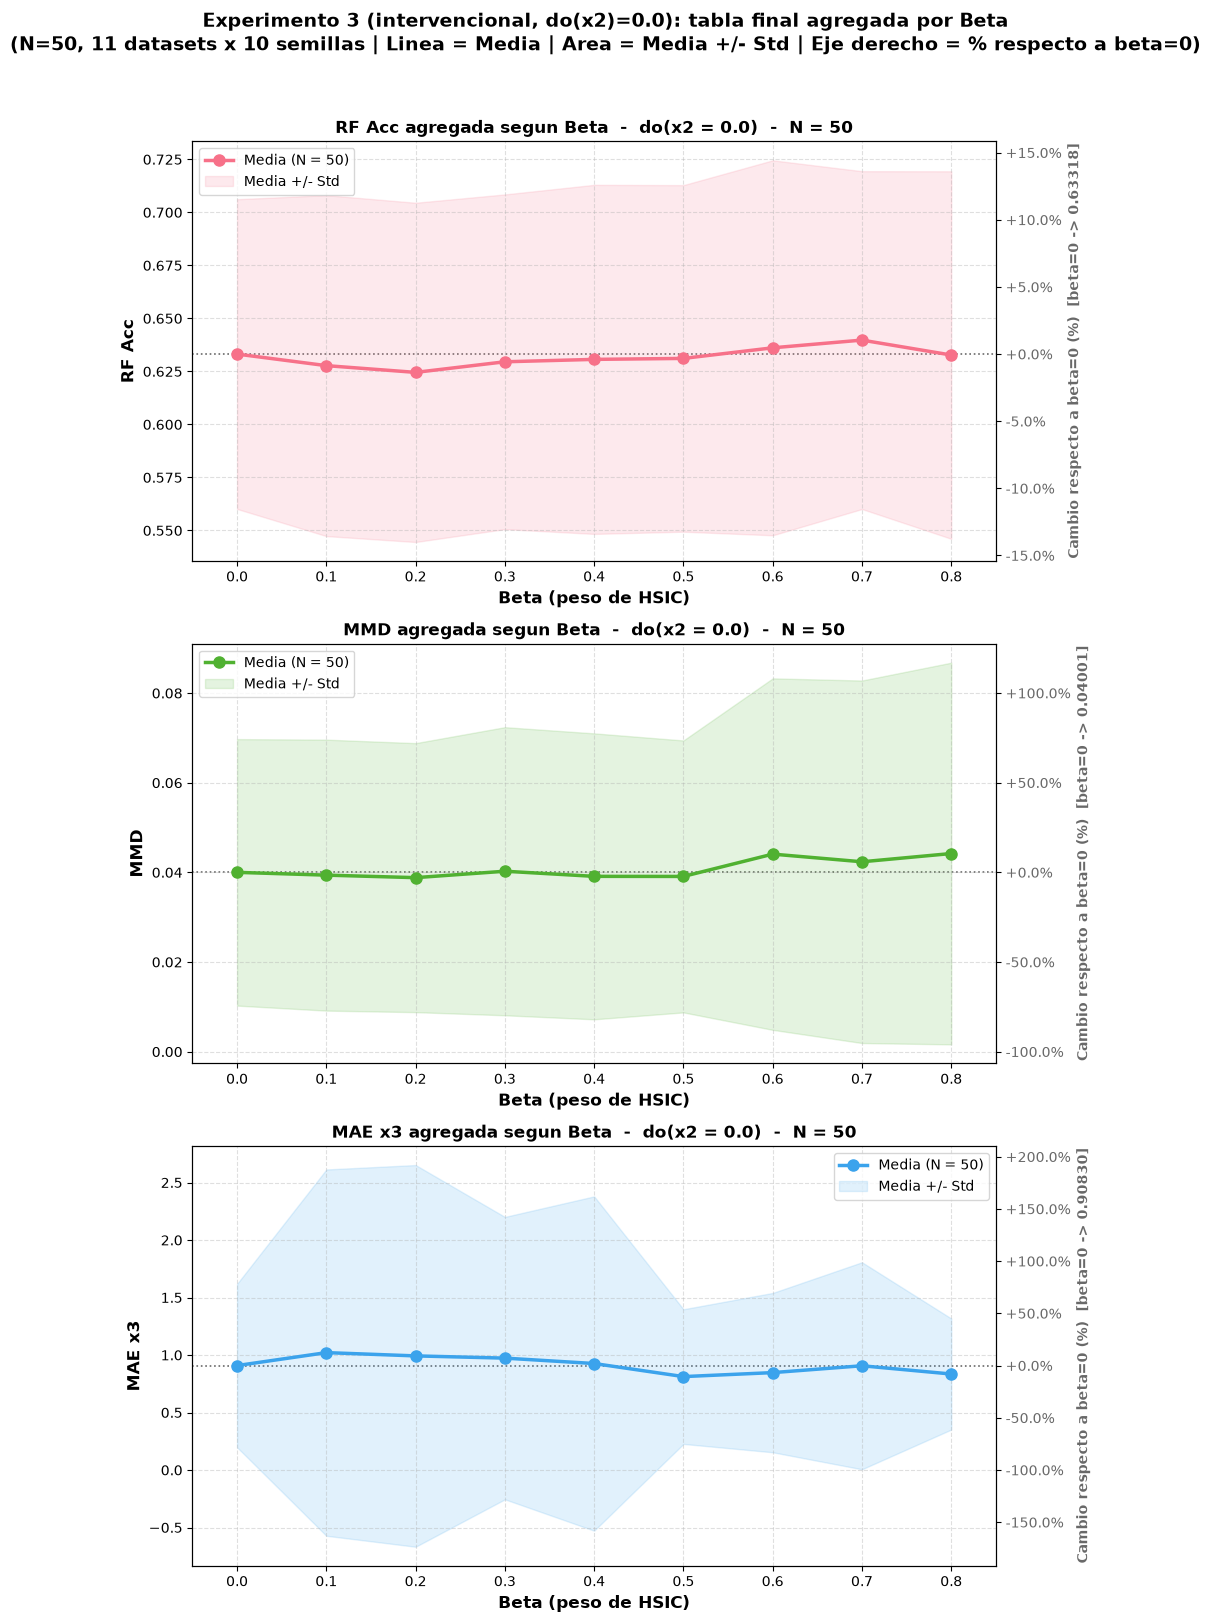

Grafica guardada: plots\bandplot_resumen_final_por_beta_intervencional_n_100.png



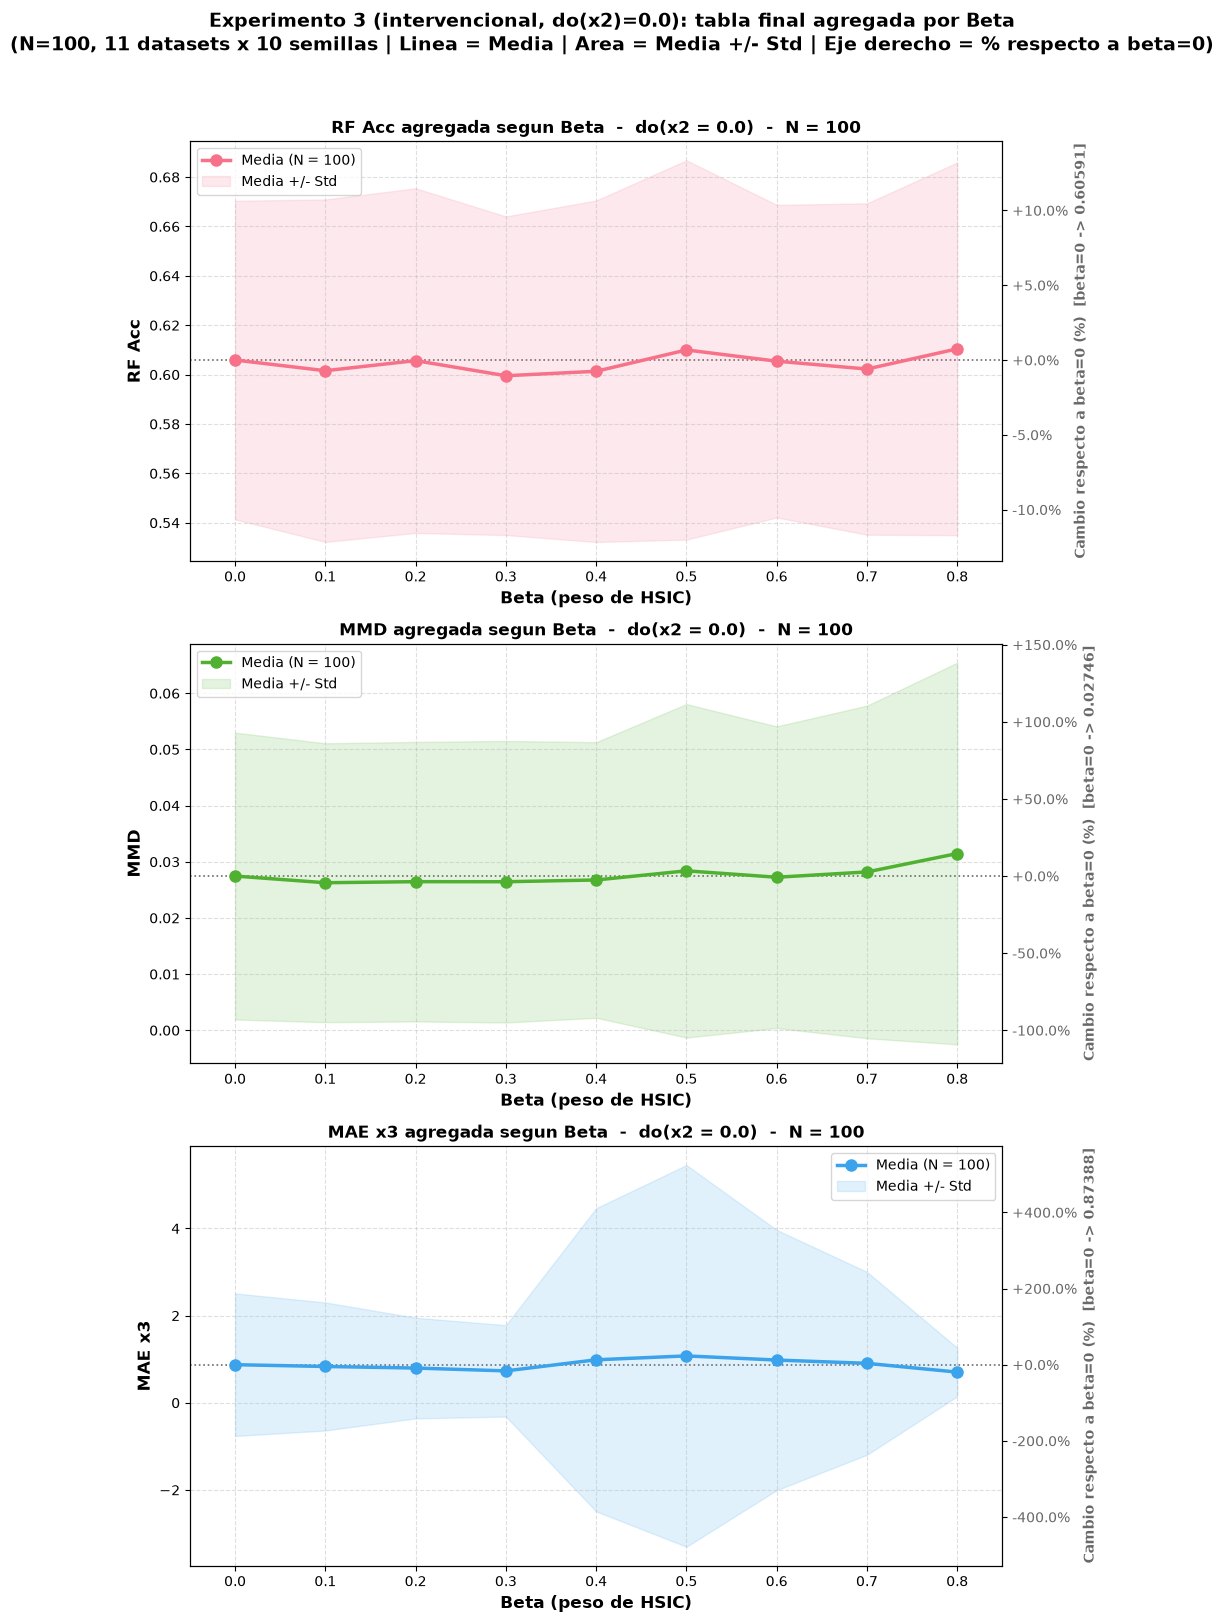


CAMBIO RELATIVO RESPECTO A BETA=0 (%)



,N,Metrica,beta=0.0,beta=0.1,beta=0.2,beta=0.3,beta=0.4,beta=0.5,beta=0.6,beta=0.7,beta=0.8
0,50,RF Acc,+0.00%,-0.86%,-1.36%,-0.57%,-0.39%,-0.32%,+0.47%,+1.04%,-0.07%
1,50,MMD,+0.00%,-1.55%,-2.95%,+0.62%,-2.22%,-2.27%,+10.17%,+5.90%,+10.50%
2,50,MAE x3,+0.00%,+12.39%,+9.26%,+7.13%,+1.96%,-10.56%,-6.75%,-0.19%,-8.09%
3,100,RF Acc,+0.00%,-0.71%,-0.04%,-1.05%,-0.75%,+0.68%,-0.08%,-0.60%,+0.75%
4,100,MMD,+0.00%,-4.33%,-3.64%,-3.68%,-2.55%,+3.39%,-0.76%,+2.66%,+14.60%
5,100,MAE x3,+0.00%,-4.69%,-8.80%,-16.27%,+12.86%,+23.10%,+12.23%,+3.55%,-19.46%


In [5]:
# PASO 9: la tabla final del PASO 8 en forma de grafica, con una figura por cada N y un panel por
# metrica (6 graficas en total). Eje X = beta, linea = media agregada sobre los 11 datasets x 10
# semillas y banda = media +/- desviacion tipica.
# El eje DERECHO es el mismo eje izquierdo reescalado a % de cambio respecto a beta=0: por
# construccion beta=0 marca el 0%, y el resto de betas se leen como su variacion relativa.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACION DE LA TABLA FINAL INTERVENCIONAL do(x2=0.0): MEDIA +/- STD AGREGADA POR BETA")
print("(Una figura por N | Linea = Media | Area sombreada = Media +/- Std)")
print("(Eje derecho = % de cambio respecto a beta=0, que marca el 0%)")
print("="*100 + "\n")

colores_metrica = dict(zip(metricas_experimento, sns.color_palette("husl", len(metricas_experimento))))

if not os.path.exists('plots'):
    os.makedirs('plots')

for n_val in valores_N_experimento:
    # Las 3 metricas se apilan en vertical: una fila por metrica.
    fig, axes = plt.subplots(len(metricas_experimento), 1, figsize=(10, 5.5 * len(metricas_experimento)))
    fig.suptitle('Experimento 3 (intervencional, do(x2)=0.0): tabla final agregada por Beta\n'
                 f'(N={n_val}, {len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas | '
                 f'Linea = Media | Area = Media +/- Std | Eje derecho = % respecto a beta=0)',
                 fontsize=14, fontweight='bold')

    for ax, metrica in zip(axes, metricas_experimento):
        df_m = df_final_resumen[(df_final_resumen['Metrica'] == metrica) &
                                (df_final_resumen['N'] == n_val)].sort_values('Beta')
        if df_m.empty:
            continue
        x = df_m['Beta'].values
        y_mean = df_m['mean'].values
        y_std = np.nan_to_num(df_m['std'].values)
        color = colores_metrica[metrica]

        ax.plot(x, y_mean, marker='o', linewidth=2.5, markersize=8, color=color, label=f'Media (N = {n_val})')
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color, label='Media +/- Std')

        ax.set_xlabel('Beta (peso de HSIC)', fontsize=12, fontweight='bold')
        ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
        ax.set_title(f'{metrica} agregada segun Beta  -  do(x2 = 0.0)  -  N = {n_val}', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xticks(valores_beta_candidatos)
        ax.set_xlim(min(valores_beta_candidatos) - 0.05, max(valores_beta_candidatos) + 0.05)
        ax.legend(loc='best', fontsize=10)

        # Eje derecho: el MISMO dato reescalado a % de cambio respecto al valor en beta=0. Se calcula
        # tras dibujar todo, porque necesita los limites definitivos del eje izquierdo.
        es_beta0 = np.isclose(x, 0.0)
        base = float(y_mean[es_beta0][0]) if es_beta0.any() else float('nan')
        if np.isfinite(base) and base != 0.0:
            ax.axhline(base, color='dimgray', linestyle=':', linewidth=1.2, zorder=0)
            lo, hi = ax.get_ylim()
            ax2 = ax.twinx()
            ax2.set_ylim((lo - base) / base * 100.0, (hi - base) / base * 100.0)
            ax2.set_ylabel(f'Cambio respecto a beta=0 (%)  [beta=0 -> {base:.5f}]',
                           fontsize=10, fontweight='bold', color='dimgray')
            ax2.tick_params(axis='y', labelcolor='dimgray')
            ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.1f}%'))
        else:
            print(f"  [aviso] {metrica} (N={n_val}): el valor en beta=0 es {base}, "
                  "no se puede calcular el % de cambio -> panel sin eje derecho.")

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    ruta_plot_final = os.path.join('plots', f'bandplot_resumen_final_por_beta_intervencional_n_{n_val}.png')
    plt.savefig(ruta_plot_final, dpi=300, bbox_inches='tight')
    print(f"Grafica guardada: {ruta_plot_final}\n")
    plt.show()


# Tabla de apoyo: los mismos porcentajes que muestra el eje derecho, en numeros.
print("\n" + "="*100)
print("CAMBIO RELATIVO RESPECTO A BETA=0 (%)")
print("="*100 + "\n")
filas_pct = []
for n_val in valores_N_experimento:
    for metrica in metricas_experimento:
        df_m = df_final_resumen[(df_final_resumen['Metrica'] == metrica) &
                                (df_final_resumen['N'] == n_val)].sort_values('Beta')
        if df_m.empty:
            continue
        base_row = df_m[np.isclose(df_m['Beta'], 0.0)]
        if base_row.empty or float(base_row['mean'].iloc[0]) == 0.0:
            continue
        base = float(base_row['mean'].iloc[0])
        fila = {'N': n_val, 'Metrica': metrica}
        for _, r in df_m.iterrows():
            fila[f"beta={r['Beta']}"] = f"{(r['mean'] - base) / base * 100.0:+.2f}%"
        filas_pct.append(fila)

df_pct = pd.DataFrame(filas_pct)
display(df_pct)